# 1. import library

In [12]:
import os
from tqdm import tqdm

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib as mpl
from svgutils.compose import Figure, SVG

# 2. import data

In [13]:
prefix = "../0_batch_experiment_data"
df = pd.read_csv(os.path.join(prefix, "cumulative_well_count_raw.csv"))

df_filtered = df[
    (df["Specie"] == "PY1") &
    (df["Condition"] == "noCFS_Cat") &
    (df["CellDensity"] != "10^5")
]
df_filtered["Hour"] = df_filtered["Day"]*24

summary = (
    df_filtered
    .groupby(["Specie", "CellDensity", "Condition", "Day"])
    .agg(
        mean=("awake_well_ratio", "mean"),
        std=("awake_well_ratio", "std"),
        n=("awake_well_ratio", "count")
    )
    .reset_index()
)
summary_n3 = summary[summary["n"] == 3].copy()

df_mutate = df_filtered.merge(
    summary_n3,
    on=["Specie", "CellDensity", "Condition", "Day"],
    how="inner"
)

/var/folders/vl/drkxtzhx2qq8zcrlhlt6cy200000gn/T/ipykernel_83301/1436834867.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Hour"] = df_filtered["Day"]*24


# 3. fitting

## 3.1. functions

In [14]:
# === FOR model(parallel parameters for each initial cell density) ===
def FOR_fit_1(cells):
    Nmax = 1 # max awake well raio
    
    # --- Tr (lag time from the onset of growth to the detection of 0.25 mM nitrite) ---
    Tr = 12.08 * 24
    
    # --- initial guess ---
    lambda0_init = 1e-4
    lagTime_init = 1*24 # minimum lag time from the onset of incubation to initial growth
    lower_bounds = [1e-8, 1e-8]
    upper_bounds = [1.0, 500*24]
    
    # --- FOR model ---
    def FOR(x, lambda0, lagTime):
        t, density = x
        effective_time = np.maximum(0, t - Tr - lagTime)
        F_t = (1 - np.exp(-lambda0 * effective_time))
        P_sleep = (1 - F_t)**density
        P_wake_up = 1 - P_sleep
        
        return Nmax * P_wake_up
    
    def parse_density(cellDensity):
        if isinstance(cellDensity, str) and cellDensity.startswith("10^"):
            return 10 ** int(cellDensity[3:])
        return float(cellDensity)
    cells = cells.copy()
    cells["density_num"] = cells["CellDensity"].apply(parse_density)

    # === fitting ===
    fit_results = []
    for (specie, celldense, cond), group in tqdm(
        cells.groupby(["Specie", "CellDensity", "Condition"])
        ):
        group = group.sort_values("Hour")
        xdata = np.vstack([
            group["Hour"].values,
            group["density_num"].values
        ])
        ydata = group["mean"].values

        try:
            popt, pcov = curve_fit(FOR, 
                                   xdata,
                                   ydata, 
                                   p0=[lambda0_init, lagTime_init],
                                   maxfev=10000,
                                   bounds=(lower_bounds, upper_bounds)
                                   )
            lambda0, lagTime = popt
            
            # --- result df ---
            for (n), group_2 in group.groupby(("N")):
                group_2 = group_2.sort_values("Hour")
                xdata = np.vstack([
                    group_2["Hour"].values,
                    group_2["density_num"].values
                ])
                n_obs = group_2["IF_population_Cumulative"].values
                
                residuals = n_obs - FOR(xdata, *popt)
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((n_obs - np.mean(n_obs))**2)
                r_squared = 1 - (ss_res / ss_tot)

                fit_results.append({
                    "Specie": specie,
                    "CellDensity": celldense,
                    "Condition": cond,
                    "N": n,
                    "lambda0": lambda0,
                    "lagTime": lagTime,
                    "r_squared": r_squared,
                    "Tr": Tr
                })
        
        except RuntimeError:
            continue
            
    fit_df = pd.DataFrame(fit_results)
    
    return(fit_df)

In [15]:
# === FOR model(same parameters for each initial cell density) ===
def FOR_fit_2(cells):
    Nmax = 1 # max awake well raio
    
    # --- Tr (lag time from the onset of growth to the detection of 0.25 mM nitrite) ---
    Tr = 12.08 * 24
    
    # --- initial guess ---
    lambda0_init = 1e-4
    lagTime_init = 1*24 # minimum lag time from the onset of incubation to initial growth
    lower_bounds = [1e-8, 1e-8]
    upper_bounds = [1.0, 500*24]
    
    # --- FOR model ---
    def FOR(x, lambda0, lagTime):
        t, density = x
        effective_time = np.maximum(0, t - Tr - lagTime)
        F_t = (1 - np.exp(-lambda0 * effective_time))
        P_sleep = (1 - F_t)**density
        P_wake_up = 1 - P_sleep
        
        return Nmax * P_wake_up
    
    def parse_density(cellDensity):
        if isinstance(cellDensity, str) and cellDensity.startswith("10^"):
            return 10 ** int(cellDensity[3:])
        return float(cellDensity)
    cells = cells.copy()
    cells["density_num"] = cells["CellDensity"].apply(parse_density)

    # === fitting ===
    xdata = np.vstack([
        cells["Hour"].values,
        cells["density_num"].values
    ])
    ydata = cells["mean"].values

    popt, pcov = curve_fit(FOR, 
                           xdata,
                           ydata, 
                           p0=[lambda0_init, lagTime_init],
                           maxfev=10000,
                           bounds=(lower_bounds, upper_bounds)
                           )
    lambda0, lagTime = popt

    # --- result df ---
    fit_results = []
    for (specie, celldense, cond, n), group in tqdm(
        cells.groupby(["Specie", "CellDensity", "Condition", "N"])
        ):
        group = group.sort_values("Hour")
        xdata = np.vstack([
            group["Hour"].values,
            group["density_num"].values
        ])
        n_obs = group["IF_population_Cumulative"].values
        
        residuals = n_obs - FOR(xdata, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((n_obs - np.mean(n_obs))**2)
        r_squared = 1 - (ss_res / ss_tot)

        fit_results.append({
            "Specie": specie,
            "CellDensity": celldense,
            "Condition": cond,
            "N": n,
            "lambda0": lambda0,
            "lagTime": lagTime,
            "r_squared": r_squared,
            "Tr": Tr
        })   
                 
    fit_df = pd.DataFrame(fit_results)
    
    return(fit_df)

In [16]:
# === Weibull model(same parameters for each initial cell density) ===
def Weibull_fit(cells):
    Nmax = 1 # max awake well raio
    
    # --- Tr (lag time from the onset of growth to the detection of 0.25 mM nitrite) ---
    Tr = 12.08 * 24
    
    # --- initial guess ---
    tau_init = 4.5e5
    k_init = 1.2
    lower_bounds = [1e-8, 0.1]
    upper_bounds = [1e8, 10.0]
    
    # --- Weibull model ---
    def Weibull(x, tau, k):
        t, density = x
        effective_time = np.maximum(0, t - Tr)
        t_scaled = effective_time / tau
        F_t = 1 - np.exp(-t_scaled**k)
        P_sleep = (1 - F_t)**density
        P_wake_up = 1 - P_sleep
        
        return Nmax * P_wake_up
    
    def parse_density(cellDensity):
        if isinstance(cellDensity, str) and cellDensity.startswith("10^"):
            return 10 ** int(cellDensity[3:])
        return float(cellDensity)
    cells = cells.copy()
    cells["density_num"] = cells["CellDensity"].apply(parse_density)

    # === fitting ===
    xdata = np.vstack([
        cells["Hour"].values,
        cells["density_num"].values
    ])
    ydata = cells["mean"].values
    
    popt, pcov = curve_fit(
        Weibull,
        xdata,
        ydata,
        p0=[tau_init, k_init],
        maxfev=10000,
        bounds=(lower_bounds, upper_bounds)
    )
    tau_fit, k_fit = popt
    
    # --- result df ---
    fit_results = []
    for (specie, celldense, cond, n), group in cells.groupby(
            ["Specie", "CellDensity", "Condition", "N"]
            ):
        t = group["Hour"].values
        density = group["density_num"].values
        n_obs = group["IF_population_Cumulative"].values
        n_pred = Weibull(
            (t, density),
            tau_fit,
            k_fit
        )
        
        residuals = n_obs - n_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((n_obs - np.mean(n_obs))**2)
        r_squared = 1 - ss_res / ss_tot

        fit_results.append({
            "Specie": specie,
            "CellDensity": celldense,
            "Condition": cond,
            "N": n,
            "tau": tau_fit,
            "k": k_fit,
            "r_squared": r_squared,
            "Tr": Tr
        })

    fit_df = pd.DataFrame(fit_results)
    
    return(fit_df)

## 3.2. fitting

In [17]:
FOR_fit_1_df = FOR_fit_1(df_mutate)
FOR_fit_2_df = FOR_fit_2(df_mutate)
Weibull_fit_df = Weibull_fit(df_mutate)

100%|██████████| 6/6 [00:00<00:00, 2097.15it/s]


# 4. Plot

## 4.1. Config

In [18]:
def set_mytheme_paper(ax):
    plt.rcParams["text.usetex"] = False
    plt.rcParams["font.family"] = "Helvetica"
    plt.rcParams["font.size"] = 8
    plt.rcParams["text.color"] = "black"
    mpl.rcParams['svg.fonttype'] = 'none'

    ax.title.set_fontsize(9.5)
    ax.title.set_color("black")
    ax.title.set_fontweight("bold")
    ax.title.set_position((0.5, 1.05))

    ax.xaxis.label.set_size(8)
    ax.yaxis.label.set_size(8)
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

    ax.tick_params(axis='x', labelsize=6.5, colors="black")
    ax.tick_params(axis='y', labelsize=6.5, colors="black")

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    ax.set_facecolor("none")
    ax.figure.set_facecolor("none")

    ax.grid(False)

    ax.legend(fontsize=8)
    ax.legend(frameon=False)

## 4.2. functions

In [19]:
def plot_FOR_fitting_result(fit_df, df_cum, fit_legend, prefix,
                            output_folder=None, IF_show=False, IF_each_plot=False, panel_label=False):

    # --- density parser ---
    def parse_density(cellDensity):
        if isinstance(cellDensity, str) and cellDensity.startswith("10^"):
            return 10 ** int(cellDensity[3:])
        return float(cellDensity)

    fit_df = fit_df.copy()
    df_cum = df_cum.copy()

    fit_df["density_num"] = fit_df["CellDensity"].apply(parse_density)
    df_cum["density_num"] = df_cum["CellDensity"].apply(parse_density)

    # --- FOR model ---
    Nmax = 1
    Tr = 12.08 * 24
    
    def FOR(x, lambda0, lagTime):
        t, density = x
        effective_time = np.maximum(0, t - Tr - lagTime)
        F_t = (1 - np.exp(-lambda0 * effective_time))
        P_sleep = (1 - F_t)**density
        P_wake_up = 1 - P_sleep
        
        return Nmax * P_wake_up

    # --- plot ---
    cell_densities = fit_df["CellDensity"].unique()
    n_cols = len(fit_df["CellDensity"].unique())
    n_rows = 4 if IF_each_plot else 1
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.5 * n_rows),
        sharex=False, sharey=True
    )
    axes = np.array(axes).reshape(n_rows, n_cols)

    for i, cellDensity in enumerate(cell_densities):
        row_fit = fit_df[fit_df["CellDensity"] == cellDensity].iloc[0]
        specie = row_fit["Specie"]
        cellDensity = row_fit["CellDensity"]
        condition = row_fit["Condition"]
        n = row_fit["N"]
        density = row_fit["density_num"]
        lambda0 = row_fit["lambda0"]
        lagTime = row_fit["lagTime"]

        t_fit = np.linspace(
            0,
            df_cum[df_cum["CellDensity"] == cellDensity]["Hour"].max(),
            300
        )
        x_fit = np.vstack([t_fit, np.full_like(t_fit, density)])
        n_fit = FOR(x_fit, lambda0, lagTime)
        
        # ---- Plot Mean(exp, n1~n3) vs Fit ----
        mean_group = (
            df_cum[
                (df_cum["Specie"] == specie) &
                (df_cum["CellDensity"] == cellDensity) &
                (df_cum["Condition"] == condition) &
                (df_cum["N"] == 1) # select only n1 to avoid multiple point
            ]
        )

        ax = axes[0, i]
        ax.errorbar(mean_group["Day"], mean_group["mean"], 
                    yerr=mean_group["std"], capsize=2, ecolor="black", elinewidth=1,
                    fmt="o", label="Observed", alpha=0.7, 
                    markeredgecolor="black", markerfacecolor="salmon")
        ax.plot(t_fit / 24, n_fit, "-", label=fit_legend, color="black")
        ax.set_xlabel("Incubation time (Day)")
        ax.set_ylabel("Fraction of wells with\nnitrite production ≥0.25 mM")
        if cellDensity == "10^1":
            ax.set_title(
                fr"10$^{1}$ cells mL$^{{-1}}$"
            )
        elif cellDensity =="10^3":
            ax.set_title(
                fr"10$^{3}$ cells mL$^{{-1}}$"
            )
        
        # calculate r-squared
        x_obs = np.vstack([mean_group["Hour"], np.full_like(mean_group["Hour"], density)])
        residuals = mean_group["mean"] - FOR(x_obs, lambda0, lagTime)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((mean_group["mean"] - np.mean(mean_group["mean"]))**2)
        r_squared = 1 - (ss_res / ss_tot)
        ax.text(
            0.025, 0.95,
            f"R² = {r_squared:.3f}\nλ = {lambda0:.2e}\nlag = {lagTime/24:.1f} (d)",
            transform=ax.transAxes,
            ha="left",
            va="top"
        )
        
        set_mytheme_paper(ax)
        
        # ---- Plot Each(exp, n1~n3) vs Fit ----
        if IF_each_plot:
            for j, n in enumerate([1, 2, 3], start=1):
                group = df_cum[
                    (df_cum["Specie"] == specie) &
                    (df_cum["CellDensity"] == cellDensity) &
                    (df_cum["Condition"] == condition) &
                    (df_cum["N"] == n)
                ].sort_values("Hour")

                if group.empty:
                    ax.axis("off")
                    continue

                ax = axes[j, i]
                ax.plot(group["Day"], group["IF_population_Cumulative"], "o", 
                        label="Observed", alpha=0.7, 
                        markeredgecolor="black", markerfacecolor="salmon")
                ax.plot(t_fit / 24, n_fit, "-", label=fit_legend, color="black")
                ax.set_xlabel("Incubation time (Day)")
                ax.set_ylabel("Fraction of wells with\nnitrite production ≥0.25 mM")
                if cellDensity == "10^1":
                    ax.set_title(
                        fr"10$^{1}$ cells mL$^{{-1}}$, N={n}"
                    )
                elif cellDensity =="10^3":
                    ax.set_title(
                        fr"10$^{3}$ cells mL$^{{-1}}$, N={n}"
                    )
                
                # row annotation
                r2 = fit_df.loc[(fit_df["CellDensity"] == cellDensity) & (fit_df["N"] == n),
                                "r_squared"
                                ].iloc[0]
                ax.text(
                    0.025, 0.95,
                    f"R² = {r2:.3f}",
                    transform=ax.transAxes,
                    ha="left",
                    va="top"
                )
                
                set_mytheme_paper(ax)
                
    # add panel label
    if panel_label is not None:
        ax0 = axes[0, 0]
        ax0.text(
            -0.2, 1.15,
            panel_label,
            transform=ax0.transAxes,
            fontsize=12, fontweight="bold",
            va="top", ha="left"
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # --- save ---
    if output_folder:
        fig.savefig(output_folder+f"/Fraction_of_wells_FOR_{prefix}.png", dpi= 600, bbox_inches="tight")
        fig.savefig(output_folder+f"/Fraction_of_wells_FOR_{prefix}.svg", format='svg', bbox_inches="tight")
        
    # --- display ---
    if IF_show == True:
        plt.show()
    else:
        plt.close()

In [20]:
def plot_Weibull_fitting_result(fit_df, df_cum, fit_legend, 
                                output_folder=None, IF_show=False, IF_hazard=False, IF_each_plot=False, panel_label=None):

    # --- density parser ---
    def parse_density(cellDensity):
        if isinstance(cellDensity, str) and cellDensity.startswith("10^"):
            return 10 ** int(cellDensity[3:])
        return float(cellDensity)

    fit_df = fit_df.copy()
    df_cum = df_cum.copy()

    fit_df["density_num"] = fit_df["CellDensity"].apply(parse_density)
    df_cum["density_num"] = df_cum["CellDensity"].apply(parse_density)

    # --- Weibull model ---
    Nmax = 1
    Tr = 12.08 * 24

    def Weibull(x, tau, k):
        t, density = x
        effective_time = np.maximum(0, t - Tr)
        
        t_scaled = effective_time / tau
        F_t = 1 - np.exp(-t_scaled**k)
        P_sleep = (1 - F_t)**density
        P_wake_up = 1 - P_sleep
        
        return Nmax * P_wake_up
    
    def Weibull_hazard(x, tau, k):
        t, _ = x
        t_scaled = t / tau
        
        f_t = k / tau * (t_scaled)**(k-1) * np.exp(-t_scaled**k)
        F_t = 1 - np.exp(-t_scaled**k)
        h_t = f_t / (1 - F_t + 1e-12)
        h_t_scaled = h_t
        
        return h_t_scaled

    # --- plot ---
    cell_densities = fit_df["CellDensity"].unique()
    n_cols = len(fit_df["CellDensity"].unique())
    n_rows = 4 if IF_each_plot else 1
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.0 * n_cols, 2.5 * n_rows),
        sharex=False, sharey=True
    )
    axes = np.array(axes).reshape(n_rows, n_cols)

    for i, cellDensity in enumerate(cell_densities):
        row_fit = fit_df[fit_df["CellDensity"] == cellDensity].iloc[0]
        specie = row_fit["Specie"]
        cellDensity = row_fit["CellDensity"]
        condition = row_fit["Condition"]
        n = row_fit["N"]
        density = row_fit["density_num"]
        tau = row_fit["tau"]
        k = row_fit["k"]

        t_fit = np.linspace(
            0,
            df_cum[df_cum["CellDensity"] == cellDensity]["Hour"].max(),
            300
        )
        x_fit = np.vstack([t_fit, np.full_like(t_fit, density)])
        n_fit = Weibull(x_fit, tau, k)
        h_t_scaled = Weibull_hazard(x_fit, tau, k)
        
        # ---- Plot Mean(exp, n1~n3) vs Fit ----
        mean_group = (
            df_cum[
                (df_cum["Specie"] == specie) &
                (df_cum["CellDensity"] == cellDensity) &
                (df_cum["Condition"] == condition) &
                (df_cum["N"] == 1) # select only n1 to avoid multiple point
            ]
        )

        ax = axes[0, i]
        ax.errorbar(mean_group["Day"], mean_group["mean"], 
                    yerr=mean_group["std"], capsize=2, ecolor="black", elinewidth=1,
                    fmt="o", label="Observed", alpha=0.7, 
                    markeredgecolor="black", markerfacecolor="salmon")
        ax.plot(t_fit / 24, n_fit, "-", label=fit_legend, color="black")
        ax.set_xlabel("Incubation time (Day)")
        ax.set_ylabel("Fraction of wells with\nnitrite production ≥0.25 mM")
        if cellDensity == "10^1":
            ax.set_title(
                fr"10$^{1}$ cells mL$^{{-1}}$"
            )
        elif cellDensity =="10^3":
                ax.set_title(
                    fr"10$^{3}$ cells mL$^{{-1}}$"
                )
        
        # hazard rate
        if IF_hazard:
            ax2 = ax.twinx()
            ax2.plot(t_fit/24, h_t_scaled, "--", color="orange", label="lambda_eff(t)")
            ax2.set_ylabel("P_cell", color="orange")
            ax2.tick_params(axis='y', labelcolor="orange")

        # calculate r-squared
        x_obs = np.vstack([mean_group["Hour"], np.full_like(mean_group["Hour"], density)])
        residuals = mean_group["mean"] - Weibull(x_obs, tau, k)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((mean_group["mean"] - np.mean(mean_group["mean"]))**2)
        r_squared = 1 - (ss_res / ss_tot)
        ax.text(
            0.025, 0.95,
            f"R² = {r_squared:.3f}\nscale = {tau/24:.1f} (d)\nshape = {k:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top"
        )
        
        set_mytheme_paper(ax)
        
        # ---- Plot Each(exp, n1~n3) vs Fit ----
        if IF_each_plot:
            for j, n in enumerate([1, 2, 3], start=1):
                group = df_cum[
                    (df_cum["Specie"] == specie) &
                    (df_cum["CellDensity"] == cellDensity) &
                    (df_cum["Condition"] == condition) &
                    (df_cum["N"] == n)
                ].sort_values("Hour")

                if group.empty:
                    ax.axis("off")
                    continue

                ax = axes[j, i]
                ax.plot(group["Day"], group["IF_population_Cumulative"], "o", 
                        label="Observed", alpha=0.7, 
                        markeredgecolor="black", markerfacecolor="salmon")
                ax.plot(t_fit / 24, n_fit, "-", label=fit_legend, color="black")
                ax.set_xlabel("Incubation time (Day)")
                ax.set_ylabel("Fraction of wells with\nnitrite production ≥0.25 mM")
                if cellDensity == "10^1":
                    ax.set_title(
                        fr"10$^{1}$ cells mL$^{{-1}}$, N={n}"
                    )
                elif cellDensity =="10^3":
                    ax.set_title(
                        fr"10$^{3}$ cells mL$^{{-1}}$, N={n}"
                    )
                
                # hazard rate
                if IF_hazard:
                    ax2 = ax.twinx()
                    ax2.plot(t_fit/24, h_t_scaled, "--", color="orange", label="lambda_eff(t)")
                    ax2.set_ylabel("Hazard rate", color="orange")
                    ax2.tick_params(axis='y', labelcolor="orange")
                
                # row annotation
                r2 = fit_df.loc[(fit_df["CellDensity"] == cellDensity) & (fit_df["N"] == n),
                                "r_squared"
                                ].iloc[0]
                ax.text(
                    0.025, 0.95,
                    f"R² = {r2:.3f}",
                    transform=ax.transAxes,
                    ha="left",
                    va="top"
                )
                
                set_mytheme_paper(ax)

    # add panel label
    if panel_label is not None:
        ax0 = axes[0, 0]
        ax0.text(
            -0.2, 1.15,
            panel_label,
            transform=ax0.transAxes,
            fontsize=12, fontweight="bold",
            va="top", ha="left"
        )
            
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # --- save ---
    if output_folder:
        fig.savefig(output_folder+"/Fraction_of_wells_Weibull.png", dpi= 600, bbox_inches="tight")
        fig.savefig(output_folder+"/Fraction_of_wells_Weibull.svg", format='svg', bbox_inches="tight")
        
    # --- display ---
    if IF_show == True:
        plt.show()
    else:
        plt.close()

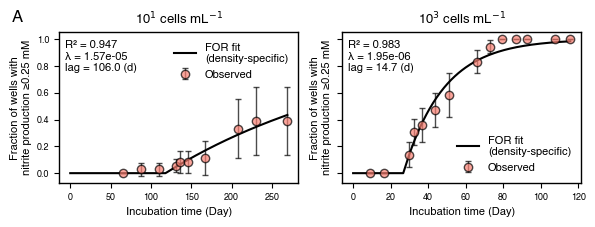

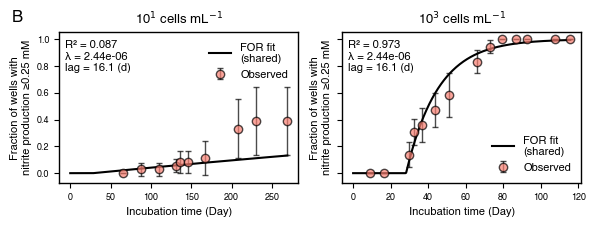

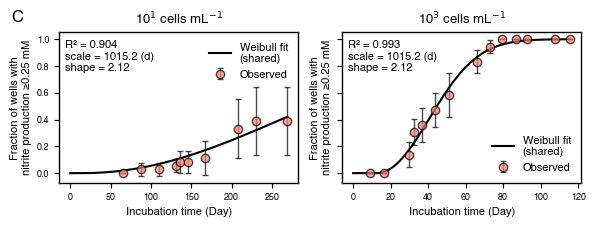

In [21]:
output_folder = "./result/deltaVt_independent_parameter"
os.makedirs(output_folder, exist_ok=True)

plot_FOR_fitting_result(FOR_fit_1_df, df_mutate, "FOR fit\n(density-specific)", "1", 
                        output_folder=output_folder, IF_show=True, IF_each_plot=False, panel_label="A")
plot_FOR_fitting_result(FOR_fit_2_df, df_mutate, "FOR fit\n(shared)", "2", 
                        output_folder=output_folder, IF_show=True, IF_each_plot=False, panel_label="B")
plot_Weibull_fitting_result(Weibull_fit_df, df_mutate, "Weibull fit\n(shared)", 
                            output_folder=output_folder, IF_show=True, IF_hazard=False, IF_each_plot=False, panel_label="C")

# 5. Image concatenate

In [22]:
prefix = "./result/deltaVt_independent_parameter"
output_folder = "../2_graph/result"
pt_to_mm = 25.4 / 72

Figure(
    "160mm", "200mm",
    SVG(os.path.join(prefix, "Fraction_of_wells_FOR_1.svg")).scale(pt_to_mm).move(0, 0),
    SVG(os.path.join(prefix, "Fraction_of_wells_FOR_2.svg")).scale(pt_to_mm).move(0, 2.5*25.4*1),
    SVG(os.path.join(prefix, "Fraction_of_wells_Weibull.svg")).scale(pt_to_mm).move(0, 2.5*25.4*2)
).save(os.path.join(output_folder, "figS.15.svg"))